In [2]:
import os
import glob

#import ants

#import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import nibabel as nib

#import SimpleITK as sitk

#from skimage.transform import resize

from concurrent.futures import ProcessPoolExecutor, as_completed

In [7]:
ROOT_DIR = "/home/fehrdelt/bettik/"
#ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [10]:
masks_acute_folder = ROOT_DIR + "datasets/final_soop_dataset_small/masks_acute_registered/"
masks_chronic_folder = ROOT_DIR + "datasets/final_soop_dataset_small/masks_chronic_registered/"

masks_combined_folder = ROOT_DIR + "datasets/final_soop_dataset_small/masks_combined_registered/"

def combine_acute_chronic_mask(acute_mask_path, chronic_mask_path, save_path):
    acute_img = nib.load(acute_mask_path)
    chronic_img = nib.load(chronic_mask_path)
    
    acute_data = acute_img.get_fdata()
    chronic_data = chronic_img.get_fdata()
    
    combined_data = np.maximum(acute_data, chronic_data)
    
    combined_img = nib.Nifti1Image(combined_data, affine=acute_img.affine, header=acute_img.header)
    
    nib.save(combined_img, save_path)
    #print(f"Saved combined mask to {save_path}")


In [11]:
# Create the combined masks folder if it doesn't exist
#os.makedirs(masks_combined_folder, exist_ok=True)

# Get all acute mask paths
acute_mask_paths = sorted(glob.glob(os.path.join(masks_acute_folder, "*.nii.gz")))

# Process each acute mask
for acute_mask_path in tqdm(acute_mask_paths, desc="Combining masks"):
    # Extract subject ID from acute mask filename
    subject = os.path.basename(acute_mask_path).split('_')[0]
    
    # Construct the corresponding chronic mask path
    chronic_mask_path = os.path.join(masks_chronic_folder, f"{subject}_space-TRACE_desc-lesionChronic_mask.nii.gz")
    
    # Check if chronic mask exists
    if os.path.exists(chronic_mask_path):
        # Construct output path for combined mask
        combined_mask_path = os.path.join(masks_combined_folder, f"{subject}_space-TRACE_desc-lesionCombined_mask.nii.gz")
        
        # Combine the masks
        combine_acute_chronic_mask(acute_mask_path, chronic_mask_path, combined_mask_path)
    else:
        # If no chronic mask exists, just copy the acute mask as the combined mask
        combined_mask_path = os.path.join(masks_combined_folder, f"{subject}_space-TRACE_desc-lesionCombined_mask.nii.gz")
        acute_img = nib.load(acute_mask_path)
        nib.save(acute_img, combined_mask_path)
        #print(f"No chronic mask found for subject {subject}, skipping combination")

Combining masks: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1451/1451 [11:38<00:00,  2.08it/s]


In [ ]:
def resample_img(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkBSpline)

    return resample.Execute(itk_image)

def resample_img_nearest_neighbor(itk_image, out_spacing=[1.0, 1.0, 1.0]):
    # Resample images to 2mspecified spacing with SimpleITK

    original_spacing = itk_image.GetSpacing()
    original_size = itk_image.GetSize()

    out_size = [
        int(np.round(original_size[0] * (original_spacing[0] / out_spacing[0]))),
        int(np.round(original_size[1] * (original_spacing[1] / out_spacing[1]))),
        int(np.round(original_size[2] * (original_spacing[2] / out_spacing[2])))]

    resample = sitk.ResampleImageFilter()
    resample.SetOutputSpacing(out_spacing)
    resample.SetSize(out_size)
    resample.SetOutputDirection(itk_image.GetDirection())
    resample.SetOutputOrigin(itk_image.GetOrigin())
    resample.SetTransform(sitk.Transform())
    resample.SetDefaultPixelValue(itk_image.GetPixelIDValue())


    resample.SetInterpolator(sitk.sitkNearestNeighbor)

    return resample.Execute(itk_image)

In [ ]:
def register_nifti_files(fixed_reference, dataset_path, output_path, register_masks=False, dataset_masks_path=None, output_masks_path=None):
    """
    Registers all NIfTI files in the dataset_path folder to the same space using ANTs.

    Parameters:
    - dataset_path: Path to the folder containing NIfTI files.
    - output_path: Path to save the registered NIfTI files.
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_path, exist_ok=True)

    # Get all NIfTI files in the dataset_path
    nifti_files = sorted(glob.glob(os.path.join(dataset_path, "*.nii*")))
    if register_masks:
        nifti_masks_files = sorted(glob.glob(os.path.join(dataset_masks_path, "*.nii*")))
    print("nifti_files", nifti_files)
    if register_masks: print("nifti_masks_files", nifti_masks_files)
    if not nifti_files:
        print("No NIfTI files found in the dataset path.")
        return

    # Use the first file as the fixed image (reference)
    fixed_image = ants.image_read(fixed_reference)

    for i, moving_file in enumerate(tqdm(nifti_files)):
        
        output_filepath = os.path.join(output_path, os.path.basename(moving_file))

        if register_masks:
            mask_file = nifti_masks_files[i]
            output_mask_filepath = os.path.join(output_masks_path, os.path.basename(mask_file))
        
        
        if not os.path.isfile(output_filepath):
            moving_image = ants.image_read(moving_file)
            
            # Perform registration
            registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

            # for the mask
            if register_masks:
                mask_image = ants.image_read(mask_file)
                transform = registration['fwdtransforms']
                mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
                mask_moved.to_file(output_mask_filepath)

            # Save the registered image
            ants.image_write(registration['warpedmovout'], output_filepath)
    
            #print(f"Registered {moving_file} and saved to {output_filepath}")
        else:
            print("skipped registration already done")


##  SOOP (FLAIR, ADC & masks)
Original Size: (281, 352, 352)\
1. no resampling since they already have isotropic resolution (2, 2, 2)
2. PAD to (352, 352, 352)
3. Resize to (128, 128, 128)
4. Register it to histogram matched MNI

In [ ]:
soop_t1w_unprocessed_folder = ROOT_DIR+"/datasets/soop_t1w_skullstrip/"
soop_flair_unprocessed_folder = ROOT_DIR+"/datasets/soop_flair_skullstrip/"
soop_adc_unprocessed_folder = ROOT_DIR+"/datasets/soop_adc_skullstrip/"
soop_masks_acute_unprocessed_folder = ROOT_DIR+"/datasets/soop_masks_acute/"
soop_masks_chronic_unprocessed_folder = ROOT_DIR+"/datasets/soop_masks_chronic/"

soop_t1w_resized_folder = ROOT_DIR+"/datasets/soop_t1w_resized/"
os.makedirs(soop_t1w_resized_folder, exist_ok=True)
soop_flair_resized_folder = ROOT_DIR+"/datasets/soop_flair_resized/"
os.makedirs(soop_flair_resized_folder, exist_ok=True)
soop_adc_resized_folder = ROOT_DIR+"/datasets/soop_adc_resized/"
os.makedirs(soop_adc_resized_folder, exist_ok=True)
soop_masks_acute_resized_folder = ROOT_DIR+"/datasets/soop_masks_acute_resized/"
os.makedirs(soop_masks_acute_resized_folder, exist_ok=True)
soop_masks_chronic_resized_folder = ROOT_DIR+"/datasets/soop_masks_chronic_resized/"
os.makedirs(soop_masks_chronic_resized_folder, exist_ok=True)

soop_t1w_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/t1w_registered/"
os.makedirs(soop_t1w_final_output_folder_registered, exist_ok=True)
soop_flair_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/flair_registered/"
os.makedirs(soop_flair_final_output_folder_registered, exist_ok=True)
soop_adc_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/adc_registered/"
os.makedirs(soop_adc_final_output_folder_registered, exist_ok=True)
soop_masks_acute_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_acute_registered/"
os.makedirs(soop_masks_acute_final_output_folder_registered, exist_ok=True)
soop_masks_chronic_final_output_folder_registered = ROOT_DIR+"/datasets/final_soop_dataset_small/masks_chronic_registered/"
os.makedirs(soop_masks_chronic_final_output_folder_registered, exist_ok=True)

#### T1w

Image 1 shape: (374, 576, 576)
Image 2 shape: (370, 512, 512)
Image 3 shape: (480, 480, 25)
Image 4 shape: (348, 1008, 1008)


<Figure size 640x480 with 0 Axes>

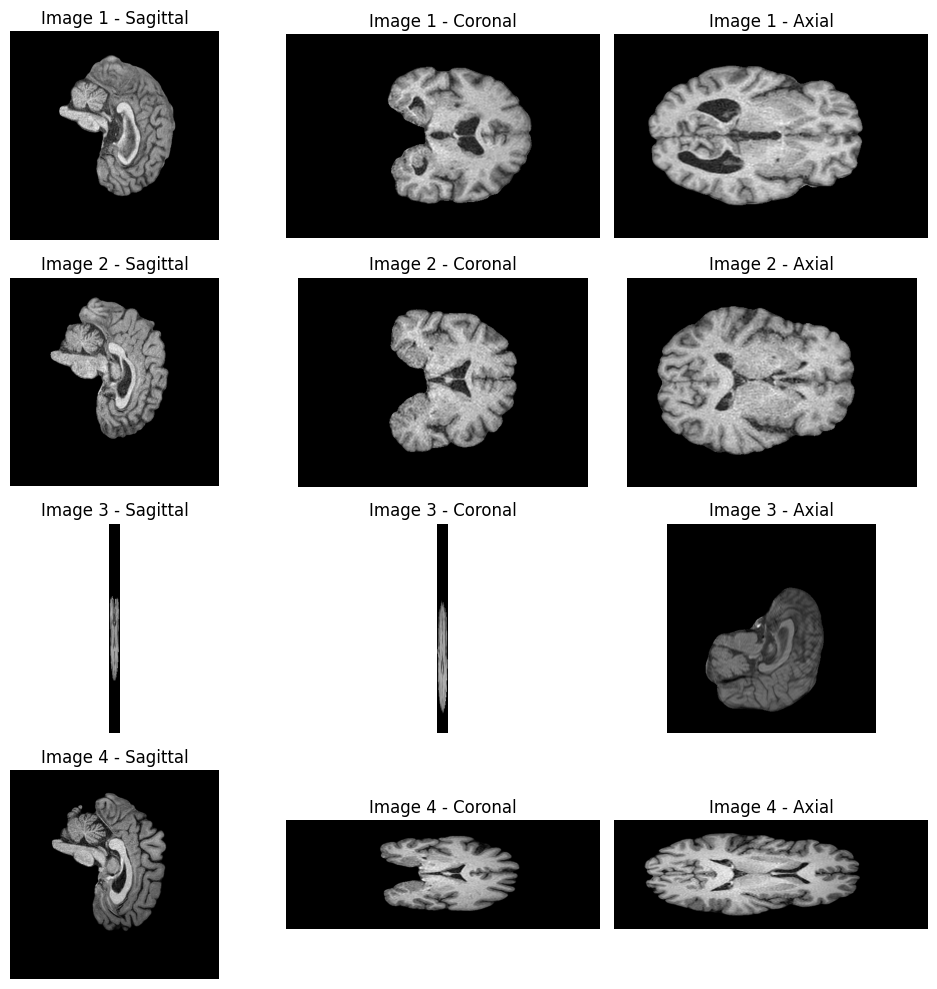

In [6]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_t1w_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
""" for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path) """

In [7]:


def process_image_resample(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"



image_paths = glob.glob(os.path.join(soop_t1w_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=64) as executor:
    futures = {executor.submit(process_image_resample, path, soop_t1w_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()


Processing images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [01:53<00:00, 15.15it/s]


Image 1 shape: (187, 247, 247)
Image 2 shape: (185, 248, 248)
Image 3 shape: (240, 240, 150)
Image 4 shape: (174, 253, 253)


<Figure size 640x480 with 0 Axes>

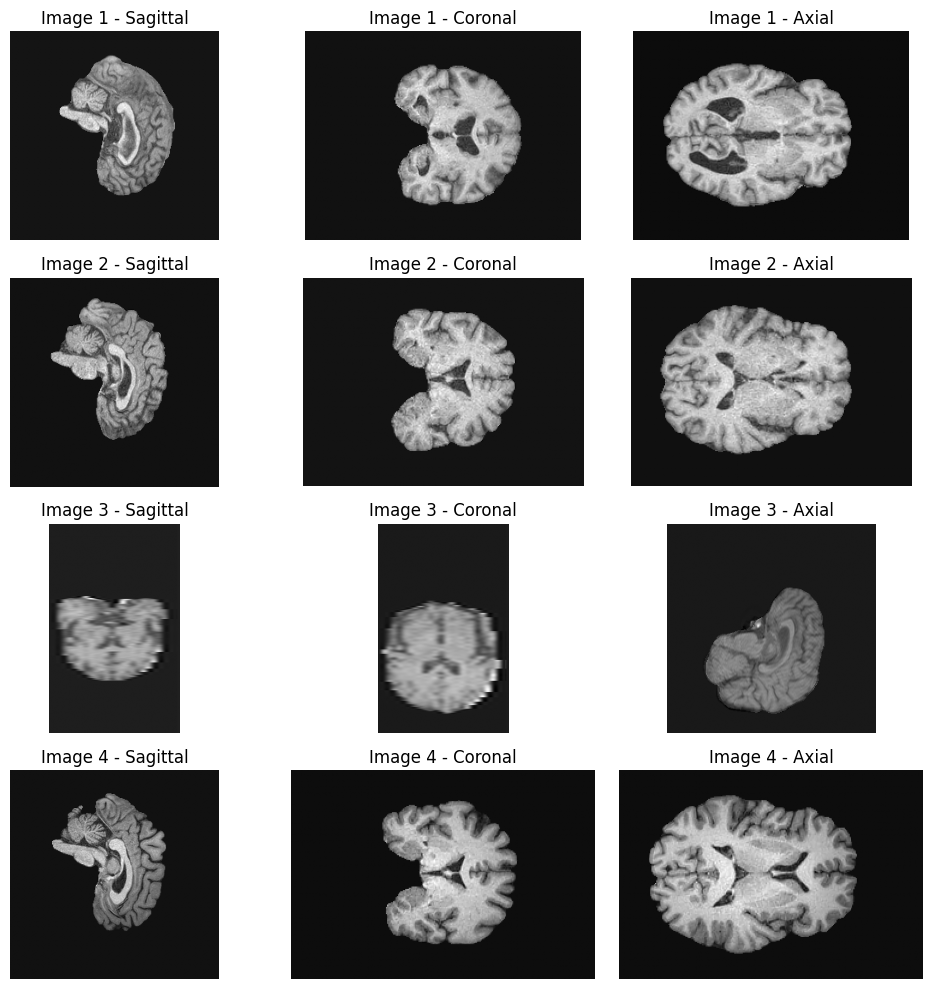

In [8]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_t1w_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Auto-orient SOOP FLAIR images to RAS orientation
def process_image_orient(image_path, output_folder):
    # Read the image with SimpleITK
    itk_image = sitk.ReadImage(image_path)
    
    # Orient to RAS (Right-Anterior-Superior)
    oriented_image = sitk.DICOMOrient(itk_image, 'RAS')
    
    # Overwrite the original file with the oriented version
    sitk.WriteImage(oriented_image, output_folder+os.path.basename(image_path))


#image_paths = glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz"))
image_paths = glob.glob(os.path.join(soop_t1w_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    #futures = {executor.submit(process_image_orient, path, soop_flair_resized_folder): path for path in image_paths}
    futures = {executor.submit(process_image_orient, path, soop_t1w_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()
        
print("All SOOP T1w images have been oriented to RAS direction.")

Processing images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [00:48<00:00, 35.20it/s]

All SOOP T1w images have been oriented to RAS direction.


Image 1 shape: (187, 247, 247)
Image 2 shape: (185, 248, 248)
Image 3 shape: (150, 240, 240)
Image 4 shape: (174, 253, 253)


<Figure size 640x480 with 0 Axes>

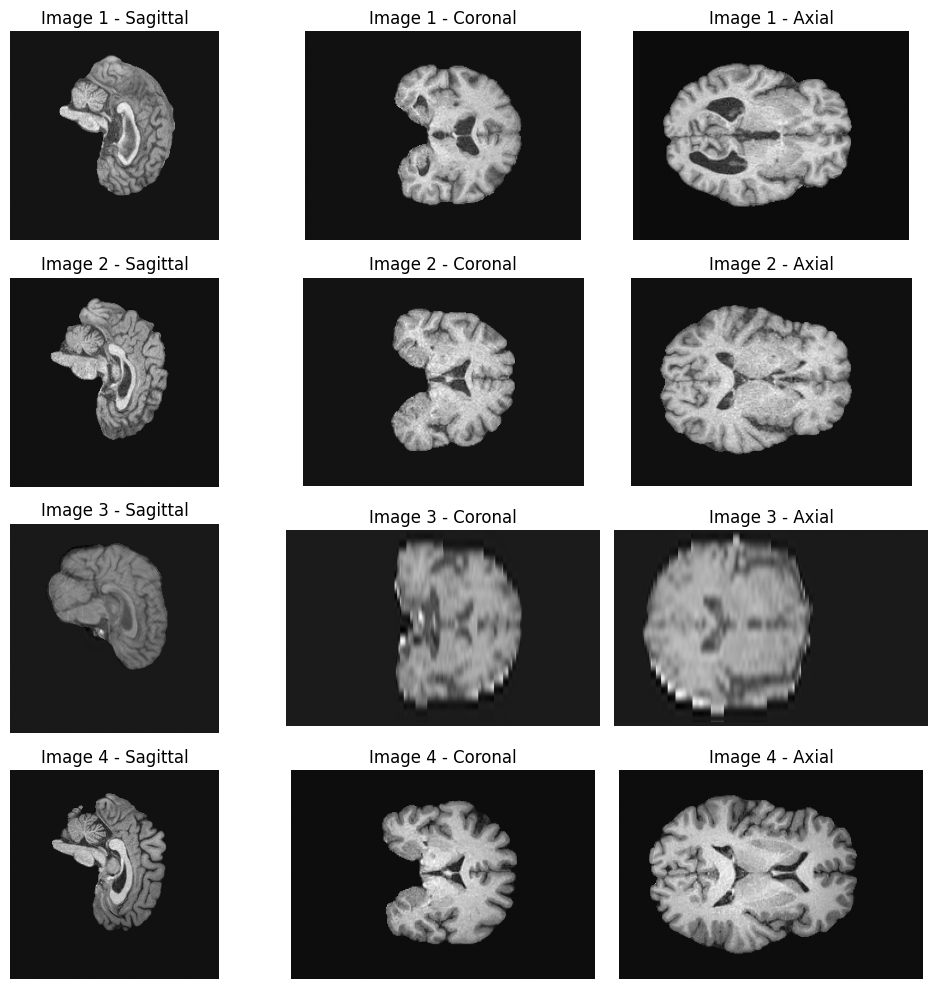

In [10]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_t1w_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Registration
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")
    t1w_image = ants.image_read(image_path)
    template_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_mni_icbm152_t1_skullstrip.nii.gz")
    atlas_image = ants.image_read(ROOT_DIR+"datasets/registered_atlas_128.nii.gz")
    output_path = ROOT_DIR+f"datasets/final_soop_dataset_small/registered_atlases/{os.path.basename(image_path)}"
    # if the output file already exists, skip
    if os.path.exists(output_path):
        return

    # Perform registration
    registration = ants.registration(fixed=t1w_image, moving=template_image, type_of_transform='antsRegistrationSyNsr') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Apply the same transform to the atlas
    warped_atlas = ants.apply_transforms(fixed=t1w_image, moving=atlas_image, transformlist=registration['fwdtransforms'], interpolator='nearestNeighbor')
    ants.image_write(warped_atlas, output_path)


image_paths = glob.glob(os.path.join(soop_t1w_final_output_folder_registered, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=64) as executor:
    futures = {executor.submit(process_image_register, path, soop_t1w_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

Processing images: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [21:05<00:00,  1.36it/s]


Image 1 shape: (128, 128, 128)
Image 2 shape: (128, 128, 128)
Image 3 shape: (128, 128, 128)
Image 4 shape: (128, 128, 128)
Image 5 shape: (128, 128, 128)
Image 6 shape: (128, 128, 128)
Image 7 shape: (128, 128, 128)
Image 8 shape: (128, 128, 128)
Image 9 shape: (128, 128, 128)
Image 10 shape: (128, 128, 128)


<Figure size 640x480 with 0 Axes>

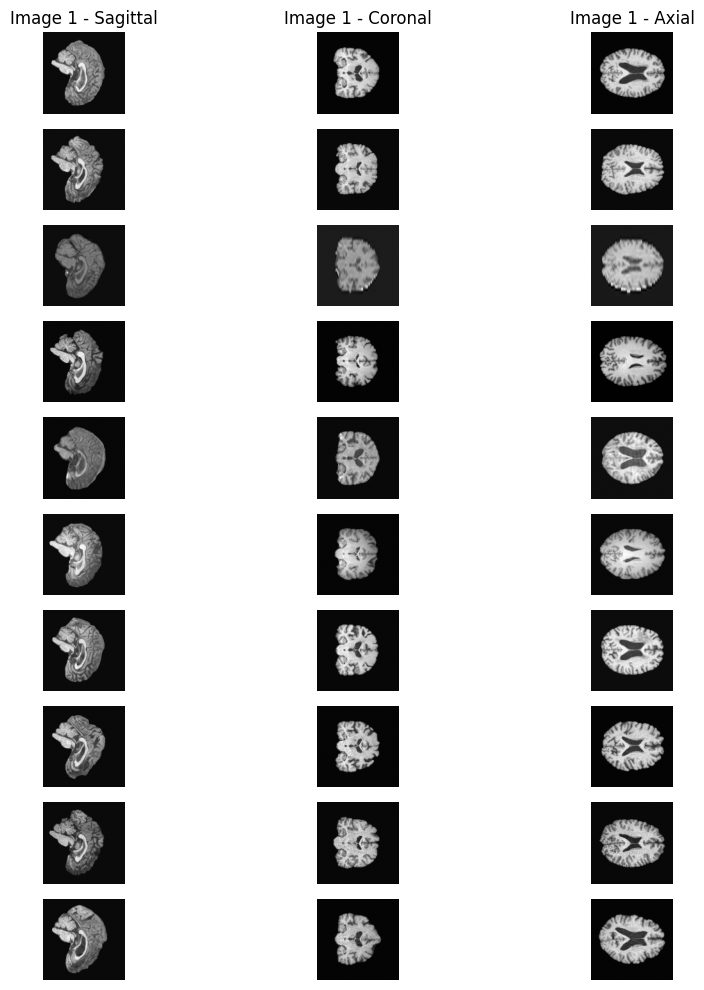

In [12]:
# Get the first 10 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_t1w_final_output_folder_registered, "*.nii.gz")))[:10]

# Plot the images
plt.suptitle("SOOP registered Images 1mm3")
fig, axes = plt.subplots(10, 3, figsize=(10, 10))

for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].axis("off")

    if i==0:
        axes[i, 0].set_title(f"Image {i+1} - Sagittal")
        axes[i, 1].set_title(f"Image {i+1} - Coronal")
        axes[i, 2].set_title(f"Image {i+1} - Axial")

plt.tight_layout()
plt.show()

#### FLAIR

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
""" for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path) """

In [ ]:


def process_image_resample(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"



image_paths = glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_flair_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Auto-orient SOOP FLAIR images to RAS orientation
def process_image_orient(image_path, output_folder):
    # Read the image with SimpleITK
    itk_image = sitk.ReadImage(image_path)
    
    # Orient to RAS (Right-Anterior-Superior)
    oriented_image = sitk.DICOMOrient(itk_image, 'RAS')
    
    # Overwrite the original file with the oriented version
    sitk.WriteImage(oriented_image, output_folder+os.path.basename(image_path))

soop_flair_skullstrip_oriented = ROOT_DIR+"datasets/soop_flair_skullstrip_oriented/"

#image_paths = glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz"))
image_paths = glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    #futures = {executor.submit(process_image_orient, path, soop_flair_resized_folder): path for path in image_paths}
    futures = {executor.submit(process_image_orient, path, soop_flair_skullstrip_oriented): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()
        
print("All SOOP FLAIR images have been oriented to RAS direction.")

Processing images: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [06:54<00:00,  4.14it/s]

All SOOP FLAIR images have been oriented to RAS direction.


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Registration
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")
    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_dallas_FLAIR_mni_icbm152_t2.nii.gz")

    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))

    #print(f"Registered {moving_file} and saved to {output_filepath}")


image_paths = glob.glob(os.path.join(soop_flair_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, soop_flair_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

In [ ]:
# Get the first 10 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_final_output_folder_registered, "*.nii.gz")))[:10]

# Plot the images
plt.suptitle("SOOP registered Images 1mm3")
fig, axes = plt.subplots(10, 3, figsize=(10, 10))

for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].axis("off")

    if i==0:
        axes[i, 0].set_title(f"Image {i+1} - Sagittal")
        axes[i, 1].set_title(f"Image {i+1} - Coronal")
        axes[i, 2].set_title(f"Image {i+1} - Axial")

plt.tight_layout()
plt.show()

#### ADC

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} {os.path.basename(image_path)} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_masks_acute_unprocessed_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} {os.path.basename(image_path)} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
""" for image_path in tqdm(glob.glob(os.path.join(soop_flair_unprocessed_folder, "*.nii.gz"))):
    itk_image = sitk.ReadImage(image_path)
    resampled_image = resample_img(itk_image)
    output_path = os.path.join(soop_flair_resized_folder, os.path.basename(image_path))
    sitk.WriteImage(resampled_image, output_path) """

In [ ]:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_image_resample(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"

def process_image_resample_nearest_neighbor(image_path, output_folder):
    try:
        itk_image = sitk.ReadImage(image_path)
        resampled_image = resample_img_nearest_neighbor(itk_image)
        output_path = os.path.join(output_folder, os.path.basename(image_path))
        sitk.WriteImage(resampled_image, output_path)
        return image_path
    except Exception as e:
        return f"Error with {image_path}: {e}"

# resample adc images
image_paths = glob.glob(os.path.join(soop_adc_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample, path, soop_adc_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

# resample acute masks with nearest neighbor
image_paths = glob.glob(os.path.join(soop_masks_acute_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample_nearest_neighbor, path, soop_masks_acute_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

# resample chronic masks with nearest neighbor
image_paths = glob.glob(os.path.join(soop_masks_chronic_unprocessed_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_resample_nearest_neighbor, path, soop_masks_chronic_resized_folder): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()


In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_resized_folder, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("Dallas Resampled Images 1mm3")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:

# Set first 4 and last 4 axial slices to zero for all mask images
all_mask_paths = glob.glob(os.path.join(soop_masks_acute_resized_folder, "*.nii.gz"))

for image_path in tqdm(all_mask_paths, desc="Processing acute masks"):
    # Load the image
    img = nib.load(image_path)
    data = img.get_fdata()
    
    # Set first 4 and last 4 axial slices to zero
    data[:, :, :5] = 0.0
    data[:, :, -5:] = 0.0
    
    # Save the modified image
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, image_path)

In [ ]:

# Set first 4 and last 4 axial slices to zero for all mask images
all_mask_paths = glob.glob(os.path.join(soop_masks_chronic_resized_folder, "*.nii.gz"))

for image_path in tqdm(all_mask_paths, desc="Processing chronic masks"):
    # Load the image
    img = nib.load(image_path)
    data = img.get_fdata()
    
    # Set first 4 and last 4 axial slices to zero
    data[:, :, :5] = 0.0
    data[:, :, -5:] = 0.0
    
    # Save the modified image
    new_img = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(new_img, image_path)

Problem: the original registration method used slightly tilts the head so that when we take an axial slice at inference, it goes through multiple thick slices which creates bad artefacts

Solution: register without rotating the brain

In [ ]:
""" # Registration withtout rotation (failed registrations)
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")

    # --- Load input images ---
    fixed_image = sitk.ReadImage(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz", sitk.sitkFloat32)
    moving_image = sitk.ReadImage(image_path, sitk.sitkFloat32)

    # --- Initialize transform ---
    # Similarity3DTransform supports uniform scaling + rotation + translation
    transform = sitk.Similarity3DTransform()

    # Set rotation to identity (no rotation)
    transform.SetMatrix(sitk.Euler3DTransform().GetMatrix())

    # --- Set up registration ---
    registration = sitk.ImageRegistrationMethod()

    # Similarity metric
    registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
    registration.SetMetricSamplingStrategy(registration.RANDOM)
    registration.SetMetricSamplingPercentage(0.2)
    registration.SetInterpolator(sitk.sitkLinear)

    # Optimizer
    registration.SetOptimizerAsGradientDescent(learningRate=1.0, numberOfIterations=200)
    registration.SetOptimizerScalesFromPhysicalShift()

    # We will freeze rotation parameters by setting only scale + translation as active
    # Parameter order: [rotation_x, rotation_y, rotation_z, translation_x, translation_y, translation_z, scale]
    # Active parameters: translation (3), scale (1)
    registration.SetInitialTransform(transform, inPlace=False)
    registration.SetOptimizerWeights([0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0])  # only scale + translation are optimized

    # --- Run registration ---
    #print("Starting registration...")
    final_transform = registration.Execute(fixed_image, moving_image)

    # --- Resample moving image ---
    registered = sitk.Resample(
        moving_image, fixed_image, final_transform, sitk.sitkLinear, 0.0, moving_image.GetPixelID()
    )

    # --- Save results ---
    #print("registration done, saving image...")
    sitk.WriteImage(registered, os.path.join(output_folder, os.path.basename(image_path)))
    
    #sitk.WriteTransform(final_transform, os.path.join(output_folder, os.path.basename(image_path)))

    #print("Registration completed successfully!")
    #print("Final transform parameters:")
    #print(final_transform)


#image_paths = glob.glob(os.path.join(soop_adc_resized_folder, "*.nii.gz"))
#process_image_register(image_paths[0], soop_adc_final_output_folder_registered)

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, soop_adc_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()  """

In [ ]:
# Registration
def process_image_register(image_path, output_folder):
    #print(f"image path: {image_path}")
    #print(f"image basename: {os.path.basename(image_path)}")
    #print(f"output path: {os.path.join(output_folder, os.path.basename(image_path))}")

    moving_image = ants.image_read(image_path)
    fixed_image = ants.image_read(ROOT_DIR+"datasets/mni_icbm152_nlin_sym_09a/128_hist_match_to_hcp_ya_FINAL_mni_icbm152_t2.nii.gz")

    masks_acute_paths = glob.glob(os.path.join(soop_masks_acute_resized_folder, "*.nii.gz"))
    masks_chronic_paths = glob.glob(os.path.join(soop_masks_chronic_resized_folder, "*.nii.gz"))

    subject = os.path.basename(image_path).split('_')[0]


    # Perform registration
    registration = ants.registration(fixed=fixed_image, moving=moving_image, type_of_transform='Similarity') # https://antspy.readthedocs.io/en/latest/registration.html types of transforms

    # if acute or chronic mask exists for this subject, register it too using the same transform
    if subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz" in [os.path.basename(p) for p in masks_acute_paths]:
        #print(f"found acute mask for subject {subject}")
        mask_image = ants.image_read(soop_masks_acute_resized_folder+subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz")
        transform = registration['fwdtransforms']
        mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
        mask_moved.to_file(soop_masks_acute_final_output_folder_registered+subject+"_space-TRACE_desc-lesionAcute_mask.nii.gz")
    
    if subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz" in [os.path.basename(p) for p in masks_chronic_paths]:
        #print(f"found chronic mask for subject {subject}")
        mask_image = ants.image_read(soop_masks_chronic_resized_folder+subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz")
        transform = registration['fwdtransforms']
        mask_moved = ants.apply_transforms(fixed_image, mask_image, transformlist=transform, interpolation='nearestNeighbor')
        mask_moved.to_file(soop_masks_chronic_final_output_folder_registered+subject+"_space-TRACE_desc-lesionChronic_mask.nii.gz")

    # Save the registered image
    ants.image_write(registration['warpedmovout'], os.path.join(output_folder, os.path.basename(image_path)))



image_paths = glob.glob(os.path.join(soop_adc_resized_folder, "*.nii.gz"))

with ProcessPoolExecutor(max_workers=32) as executor:
    futures = {executor.submit(process_image_register, path, soop_adc_final_output_folder_registered): path for path in image_paths}

    for future in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
        _ = future.result()

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_flair_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP flair registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_adc_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP adc registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Get the first 4 image paths from the folder
image_paths = sorted(glob.glob(os.path.join(soop_masks_acute_final_output_folder_registered, "*.nii.gz")))[:4]

# Plot the images
plt.suptitle("SOOP masks acute registered")
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
for i, image_path in enumerate(image_paths):
    image = nib.load(image_path).get_fdata()
    print(f"Image {i+1} shape: {image.shape}")
    # Extract slices
    axial_slice = image[image.shape[0] // 2, :, :]  # Middle axial slice
    sagittal_slice = image[:, image.shape[1] // 2, :]  # Middle sagittal slice
    coronal_slice = image[:, :, image.shape[2] // 2]  # Middle coronal slice

    # Plot slices
    axes[i, 0].imshow(axial_slice, cmap="gray")
    axes[i, 0].set_title(f"Image {i+1} - Sagittal")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(sagittal_slice, cmap="gray")
    axes[i, 1].set_title(f"Image {i+1} - Coronal")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(coronal_slice, cmap="gray")
    axes[i, 2].set_title(f"Image {i+1} - Axial")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Get sorted file paths for both flair images and masks
flair_paths = sorted(glob.glob(os.path.join(soop_adc_final_output_folder_registered, "*.nii.gz")))

# Take first 10 pairs for visualization
num_pairs = min(20, len(flair_paths))

fig, axes = plt.subplots(num_pairs, 6, figsize=(18, 3*num_pairs))
plt.suptitle("ISLES flair Images and Corresponding Masks (Registered)", fontsize=16)

for i in range(num_pairs):
    # Load flair image and mask
    flair_img = nib.load(flair_paths[i]).get_fdata()
    try:
        mask_img = nib.load(soop_masks_acute_final_output_folder_registered+os.path.basename(flair_paths[i]).split("_")[0] + "_space-TRACE_desc-lesionAcute_mask.nii.gz").get_fdata()
    except Exception as e:
        print(f"Error loading mask image for flair {i+1}: {e}")
        continue

    # Get middle slices
    mid_slice = flair_img.shape[2] // 2
    flair_axial = flair_img[:, :, mid_slice]
    mask_axial = mask_img[:, :, mid_slice]
    
    mid_slice_sag = flair_img.shape[0] // 2
    flair_sagittal = flair_img[mid_slice_sag, :, :]
    mask_sagittal = mask_img[mid_slice_sag, :, :]
    
    mid_slice_cor = flair_img.shape[1] // 2
    flair_coronal = flair_img[:, mid_slice_cor, :]
    mask_coronal = mask_img[:, mid_slice_cor, :]
    
    # Plot flair sagittal
    axes[i, 0].imshow(flair_sagittal, cmap="gray")
    axes[i, 0].set_title(f"flair {i+1} - Sagittal" if i == 0 else "")
    axes[i, 0].axis("off")
    
    # Plot flair coronal
    axes[i, 1].imshow(flair_coronal, cmap="gray")
    axes[i, 1].set_title(f"flair {i+1} - Coronal" if i == 0 else "")
    axes[i, 1].axis("off")
    
    # Plot flair axial
    axes[i, 2].imshow(flair_axial, cmap="gray")
    axes[i, 2].set_title(f"flair {i+1} - Axial" if i == 0 else "")
    axes[i, 2].axis("off")
    
    # Plot Mask sagittal
    axes[i, 3].imshow(mask_sagittal, cmap="Reds")
    axes[i, 3].set_title(f"Mask {i+1} - Sagittal" if i == 0 else "")
    axes[i, 3].axis("off")
    
    # Plot Mask coronal
    axes[i, 4].imshow(mask_coronal, cmap="Reds")
    axes[i, 4].set_title(f"Mask {i+1} - Coronal" if i == 0 else "")
    axes[i, 4].axis("off")
    
    # Plot Mask axial
    axes[i, 5].imshow(mask_axial, cmap="Reds")
    axes[i, 5].set_title(f"Mask {i+1} - Axial" if i == 0 else "")
    axes[i, 5].axis("off")

plt.tight_layout()
plt.show()